## Chapter 6


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP.models import ModelSpec as MS
from functools import partial

# New imports
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import (
    Stepwise,
    sklearn_selected,
    sklearn_selection_path
)
from l0bnb import fit_path

# My addition
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
import warnings

### Question 8

#### 8a)

In [2]:
# Generate a simulated dataset
rng = np.random.default_rng(42)
x = rng.normal(size=100)
e = rng.normal(size=100)

#### 8b)

In [3]:
# Generate y
y = 1 + 2*x + 3*(x**2) + 4*(x**3) + e

#### 8c)

In [4]:
# Add intercept
X = np.ones(len(x)).reshape(-1, 1) # reshape so it becomes 2D

# Generate features/predictors
for i in range(1, 11):
    new_array = np.array(x**i).reshape(-1, 1)
    X = np.concatenate((X, new_array), axis=1)

In [5]:
def forward_step(X, y, scoring_fun, sigma2=None, k=5, method='cv'):    
    # Initialize variables
    features_selected = [0] # intercept (and/or others)
    features_remaining = [x for x in range(X.shape[1]) if x not in features_selected]
    best_scores = []
    
    while features_remaining:
        best_feature = None
        best_score = float('inf')

        for feature in features_remaining:
            features_current = features_selected + [feature]
            
            # Going for cross-validation method
            if method == 'cv':
                kfold = skm.KFold(n_splits=k, shuffle=True, random_state=42)
                kfold_scores = []
    
                # K-fold cross-validation
                for train, val in kfold.split(X):
    
                    # Split the data
                    X_train, X_val = X[np.ix_(train, features_current)], X[np.ix_(val, features_current)]
                    y_train, y_val = y[train], y[val]
    
                    # Fit model & get scores
                    kfold_model = OLS(y_train, X_train).fit()
                    if sigma2:
                        kfold_scores.append(scoring_fun(kfold_model, y_val, X_val, sigma2))
                    else:
                        kfold_scores.append(scoring_fun(kfold_model, y_val, X_val))
                    
                # Compute 'cv_score' from 'kfold_scores'
                cv_score = np.mean(kfold_scores)

                # Check if it is the 'best_score'
                if cv_score < best_score:
                    best_score = cv_score
                    best_feature = feature
                
            # Going for standard method
            else:
                model = OLS(y, X[:, features_current]).fit()
                if sigma2:
                    score = scoring_fun(model, y, X[:, features_current], sigma2)
                else:
                    score = scoring_fun(model, y, X[:, features_current])

                if score < best_score:
                    best_score = score
                    best_feature = feature

        # Update variables
        features_selected.append(best_feature)
        features_remaining.remove(best_feature)
        best_scores.append(best_score)
                    
    return features_selected, best_scores

In [6]:
# Create a function to score MSE
def compute_mse(model, y, X):
    y_hat = model.predict(X)
    rss = sum((y - y_hat)**2)
    mse = rss / len(y)
    return mse

In [7]:
# Create a function to score Cp
def compute_Cp(model, y, X, sigma2):
    n, p = X.shape
    y_hat = model.predict(X)
    rss = sum((y - y_hat)**2)
    Cp = (rss + 2*p*sigma2) / n
    return Cp

In [8]:
# Compute sigma2 based on MSE
sigma2 = OLS(y, X).fit().scale
sigma2

0.9597290861769214

In [9]:
# Perform forward stepwise selection
features, scores = forward_step(X, y, compute_Cp, sigma2=sigma2, method='regular')

# Fit null model & score
model_null = OLS(y, X[:, 0]).fit()
score_null = compute_Cp(model_null, y, X[:, 0].reshape(-1,1), sigma2)

# Add score_null to scores
scores = [score_null] + scores

# Fit the model
model = OLS(y, X[:, features]).fit()

# Build answer
answer = pd.DataFrame(zip(features, scores), columns=['features','scores'])
answer.insert(1, 'coefs', model.params)
answer.style.hide(axis='index')

features,coefs,scores
0,0.984720,62.623810
3,8.078295,6.073245
2,3.030170,1.788008
1,1.207577,0.987305
9,-0.336038,0.998821
5,-5.681938,1.011529
8,1.623245,1.028291
7,2.606023,1.038653
4,1.999247,1.056390
10,-0.211779,1.050307


Based on the implemented logic, feature 0 represents the intercept, feature 1 corresponds to $x^1$, feature 2 to $x^2$, and so on.

It is entirely logical that $x^3$ is selected first, as our generated data assigns it the highest coefficient value. This is followed by $x^2$ and then $x^1$, reflecting the order of importance in the data. The forward stepwise selection process aligns with this prioritization, selecting features in the same sequence order.

The scores show no further improvement starting from the inclusion of the 5th feature onward, which is consistent with the structure of the generated data.

#### 8d)

In [12]:
"""
obs: I'm not 100% confident this is working as expected.
"""
# Create a function for backwards stepwise selection
def backwards_stepwise(X, y, scoring_fun, sigma2=None, k=5, method='cv'):
    features_selected = [0] # intercept first
    features_remaining = list(range(X.shape[1]))
    best_scores = []

    while features_remaining:
        best_feature = None
        best_score = -float('inf')

        for feature in features_remaining[1:]: # exclude intercept
            features_current = [x for x in features_remaining if x != feature]

            # Prevent empty feature
            if not feature:
                continue
            
            # Follow k-fold cross-validation method
            if method == 'cv':
                kfold_scores = []
                kfold = skm.KFold(n_splits=k, shuffle=True, random_state=42)

                # Loop through each fold
                for train, val in kfold.split(X):
                    X_train, X_val = X[np.ix_(train, features_current)], X[np.ix_(val, features_current)]
                    y_train, y_val = y[train], y[val]

                    # Fit a model and get the score
                    kfold_model = OLS(y_train, X_train).fit()
                    if sigma2:
                        kfold_score = scoring_fun(kfold_model, y_train, X_train, sigma2)
                    else:
                        kfold_score = scoring_fun(kfold_model, y_train, X_train)
                    kfold_scores.append(kfold_score)

                # Compute cross-validation score
                cv_score = np.mean(kfold_scores)

                # Check if it is the 'best_score'
                if cv_score > best_score:
                    best_score = cv_score
                    best_feature = feature
                
            # Follow 'standard' method
            else:
                # Fit a model and get the score
                model = OLS(y, X[:, features_current]).fit()
                if sigma2:
                    score = scoring_fun(model, y, X[:, features_current], sigma2)
                else:
                    score = scoring_fun(model, y, X[:, features_current])

                # Check if it is the 'best_score'
                if score > best_score:
                    best_score = score
                    best_feature = feature

        # If there are no more features
        if not best_feature:
            break

        # Update variables
        features_selected.append(best_feature)
        features_remaining.remove(best_feature)
        best_scores.append(best_score)

    return features_selected, best_scores    

In [13]:
# Perform bacwards stepwise selection
features_back, scores_back = backwards_stepwise(X, y, compute_Cp, sigma2=sigma2, method='standard')

# Fit null model & score
model_null = OLS(y, X[:, 0]).fit()
score_null = compute_Cp(model_null, y, X[:, 0].reshape(-1,1), sigma2)

# Add score_null to scores
scores_back = [np.nan] + scores_back

# Fit the model
model = OLS(y, X[:, features]).fit()

# Build answer
answer_back = pd.DataFrame(zip(features_back, scores_back), columns=['features','scores'])
answer_back.insert(1, 'coefs', model.params)
answer_back.style.hide(axis='index')

features,coefs,scores
0,0.984720,nan
3,8.078295,1.117102
1,3.030170,2.029739
5,1.207577,5.931811
7,-0.336038,16.903794
9,-5.681938,20.573692
10,1.623245,23.370874
8,2.606023,32.418265
6,1.999247,54.926108
4,-0.211779,61.530556


When performing backward stepwise selection for feature selection, the results differ significantly from those of forward stepwise selection. This discrepancy is likely due to the issue of multicolinearity when starting with a model including all features. A linear regression model struggles to accurately determine the individual significance of each variable. This can lead to the undesirable exclusion of important features early in the backward selection process, negatively affecting thee final model.

obs: I'm not 100% confident the function is working as expected.

8e)

In [14]:
# Set up a scaler method for the data
scaler = StandardScaler(with_mean=True, with_std=True)

# Set up k-fold cross-validation
k=5
kfold = skm.KFold(
    k,
    random_state=42,
    shuffle=True
)

# Set up lasso regularization method
lasso_cv = skl.ElasticNetCV(
    n_alphas=100, # auto generated lambdas
    l1_ratio=1,
    cv=kfold,
    #fit_intercept=False
)

# Create a pipeline
pipe_cv = Pipeline(
    steps=[
        ('scaler', scaler),
        ('lasso', lasso_cv)
    ]
)

# Fit
pipe_cv.fit(X[:, 1:], y)

# Get lasso details
tuned_lasso = pipe_cv.named_steps['lasso']

# Show results - best lambda
tuned_lasso.alpha_

0.030363566043005035

In [15]:
# Show coefficient values with best results (smallest MSE)
tuned_lasso.coef_

array([1.46101049, 2.19981432, 6.63372297, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [16]:
# Show the intercept
tuned_lasso.intercept_

2.074374715839319

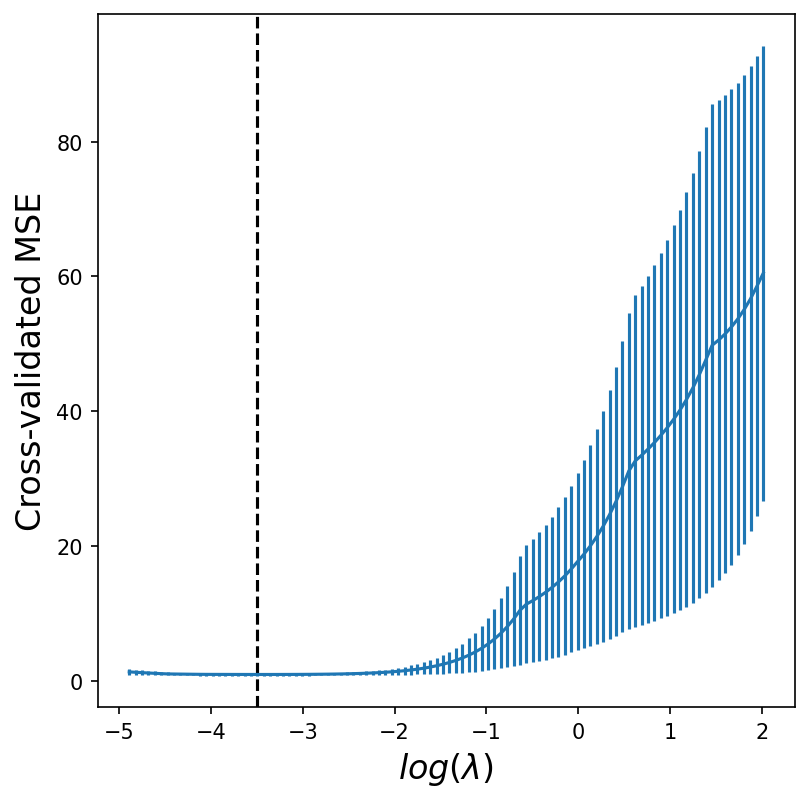

In [17]:
# Create a plot
lasso_cv_fig, ax = plt.subplots(figsize=(6,6), dpi=150)
ax.errorbar(
    np.log(tuned_lasso.alphas_),
    tuned_lasso.mse_path_.mean(1),
    yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(k)
)
ax.axvline(np.log(tuned_lasso.alpha_), c='k', ls='--')
ax.set_xlabel(r'$log(\lambda)$', fontsize=16)
ax.set_ylabel('Cross-validated MSE', fontsize=16);

When performing Lasso regularization, the optimal $\lambda$ value for minimizing the MSE is 0.03306. However, there appears to be a range of $\lambda$ values that yield similar results.

Similar to the forward stepwise selection method, Lasso successfully identified the correct three coefficients.

#### 8f)

In [18]:
# Generate new data
y = 1 + 7*(x**7) + e

In [19]:
# Perform forward stepwise
features, scores = forward_step(X, y, compute_Cp, sigma2=sigma2, method='cv')

# Fit null model & score
model_null = OLS(y, X[:, 0]).fit()
score_null = compute_Cp(model_null, y, X[:, 0].reshape(-1,1), sigma2)

# Add score_null to scores
scores = [score_null] + scores

# Fit the model
model = OLS(y, X[:, features]).fit()

# Build answer
answer = pd.DataFrame(zip(features, scores), columns=['features','scores'])
answer.insert(1, 'coefs', model.params)
answer.style.hide(axis='index')

features,coefs,scores
0,0.984720,28482.056452
7,9.606023,1.659587
2,0.030170,1.530933
1,-0.792423,1.984121
5,-5.681938,1.721392
3,4.078295,1.822397
4,1.999247,1.882158
6,-3.456002,41.673298
9,-0.336038,255.161287
8,1.623245,62.886208


The forward stepwise method correclty identifies $x^7$ as the best predictor, which aligns with the generated data. However, it unexpectedly assigns a small level of relevance to $x^2$, which does not match the generated data.


In [1446]:
# Set up a scaler method for the data
scaler = StandardScaler(with_mean=True, with_std=True)

# Set up k-fold cross-validation
k=5
kfold = skm.KFold(
    k,
    random_state=42,
    shuffle=True
)

# Set up lasso regularization method
lasso_cv = skl.ElasticNetCV(
    n_alphas=100, # auto generated lambdas
    l1_ratio=1,
    cv=kfold,
    #fit_intercept=False
)

# Create a pipeline
pipe_cv = Pipeline(
    steps=[
        ('scaler', scaler),
        ('lasso', lasso_cv)
    ]
)

# Fit
pipe_cv.fit(X[:, 1:], y)

# Get lasso details
tuned_lasso = pipe_cv.named_steps['lasso']

# Show results - best lambda
tuned_lasso.alpha_

0.16876341715531037

In [1447]:
# Show coefficient values with best results (smallest MSE)
tuned_lasso.coef_

array([ -0.59400525,  -0.        ,   0.        ,  -0.        ,
        21.90321861,  -0.96705146, 113.01631354,  -0.        ,
        35.01753179,  -0.        ])

In [1448]:
# Show intercept
tuned_lasso.intercept_

0.5126977645759988

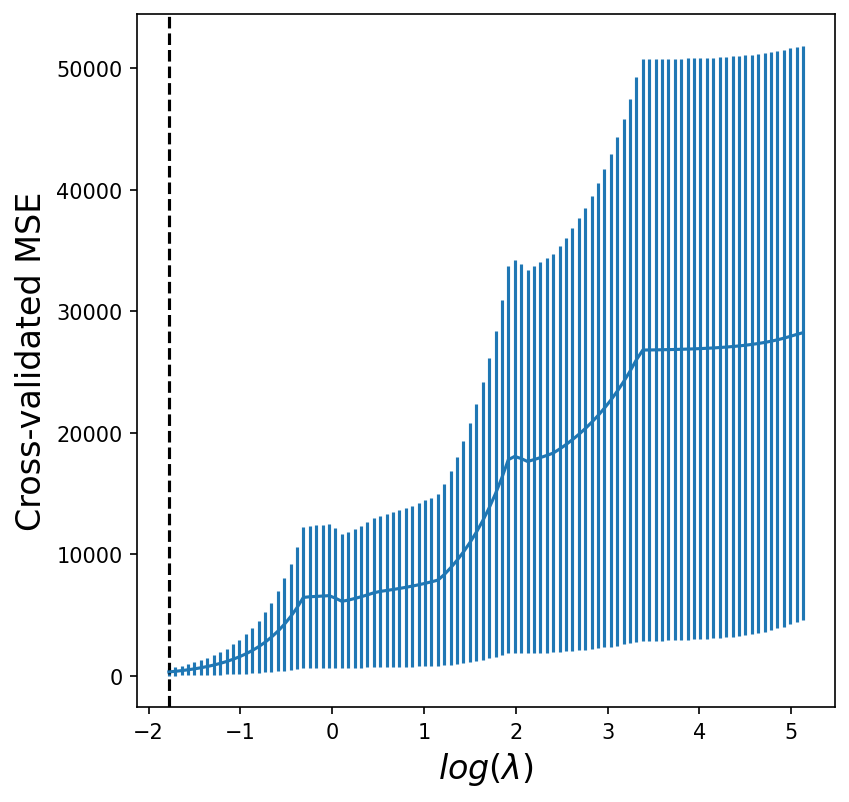

In [1449]:
# Create a plot
lasso_cv_fig, ax = plt.subplots(figsize=(6,6), dpi=150)
ax.errorbar(
    np.log(tuned_lasso.alphas_),
    tuned_lasso.mse_path_.mean(1),
    yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(k)
)
ax.axvline(np.log(tuned_lasso.alpha_), c='k', ls='--')
ax.set_xlabel(r'$log(\lambda)$', fontsize=16)
ax.set_ylabel('Cross-validated MSE', fontsize=16);

Lasso accurately identifies $x^7$ as the most significant feature, which aligns witht the generated data. However, it also incorreclty assigns $x^5$ and $x^9$ with lesser coefficient values.

obs: $x^1$ and $x^6$ receives insignificant coefficient values when compared to the others.

---

### Question 9

#### 9a)

In [1450]:
# Load college data
college = pd.read_csv('data/College.csv')

In [1451]:
# Get initial dataset info
college.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   777 non-null    object 
 1   Private      777 non-null    object 
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          777 non-null    int64  
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: float

In [1452]:
# Get the first observations
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [1453]:
# Rename columns
college.columns = [
    'college_name',
    'private',
    'apps',
    'accept',
    'enroll',
    'top10perc',
    'top25perc',
    'fulltime_underg',
    'parttime_underg',
    'outstate',
    'costs_room_board',
    'costs_books',
    'costs_personal',
    'phd',
    'terminal',
    'student_faculty_ratio',
    'perc_alumni_donation',
    'expend_per_student',
    'grad_rate'
]

In [1454]:
# Create dummy for 'private'
college['private'] = college['private'].apply(lambda x: 1 if x=='Yes' else 0)

In [1455]:
# Get exog and endog variables
X = college.drop(['college_name', 'apps'], axis=1)
y = college['apps']

In [1456]:
# Split data
X_train, X_test, y_train, y_test = skm.train_test_split(
    X, y, random_state=42
)

#### 9b)

In [1457]:
# Scale dataset
X_train_s = X_train - X_train.mean()
X_train_s = X_train_s / X_train.std()

X_test_s = X_test - X_train.mean()
X_test_s = X_test_s / X_train.std()

In [1458]:
# Create and fit the model on train dataset
model = OLS(y_train, X_train_s).fit()

In [1459]:
# Predict on test dataset
y_pred = model.predict(X_test_s)

# Compute RSS
rss = sum((y_test - y_pred)**2)

# Compute and show MSE
mse_ols = rss / len(y_test)
round(mse)

1817983

When we fit a linear model using least squared on the training set, we get the result above of 11,044,133 for MSE on the testing set.

#### 9c)

In [1460]:
# Set up a scaler method for the data
scaler = StandardScaler(with_mean=True, with_std=True)

# Get a grid/range of lambda values to test
lambdas = 10**np.linspace(6, -2, 100) / y_train.std()

# Parameter grid for GridSearchCV
param_grid = {'ridge__alpha': lambdas}

# Set up k-fold cross-validation
k = 5
kfold = KFold(
    n_splits=k,
    random_state=42,
    shuffle=True
)

# Set up Ridge regularization method
ridge = Ridge()

# Create a pipeline
pipe_cv = Pipeline(
    steps=[
        ('scaler', scaler),
        ('ridge', ridge)
    ]
)

# Perform Grid Search with cross-validation
grid = GridSearchCV(
    pipe_cv, 
    param_grid, 
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1 # use all available CPU cores
)

# Fit GridSearchCV
grid.fit(X_train, y_train)

# Extract the best parameters and score
best_lambda = grid.best_params_['ridge__alpha']
best_score = -grid.best_score_
best_model = grid.best_estimator_

# Output results
print(f"""
Best lambda: {best_lambda}

Best MSE: {round(best_score)}

Best model: {best_model}
""")


Best lambda: 2.531589211679931e-06

Best MSE: 1234368

Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('ridge', Ridge(alpha=2.531589211679931e-06))])



In [1461]:
# Compute MSE on test dataset
y_hat = best_model.predict(X_test)
rss = sum((y_test - y_hat)**2)
mse_ridge = rss / len(y_hat)

# Print MSE on test dataset
print(f"""
Test MSE: {round(mse_ridge)}
""")


Test MSE: 1817983



When conducting a grid search to determine the best $\lambda$ through cross-validation with the Ridge method, we achieve a test MSE of 1,817,983. This represents a significant improvement compared to the tesst MSE of 11,044,133 obtained from the standard linear regression model.

#### 9d)

In [1462]:
# Set up a scaler method
scaler = StandardScaler(with_mean=True, with_std=True)

# Get a range of lambdas to test
lambdas = 10**np.linspace(6, -2, 100) / y_train.std()

# Set up a grid search paramenter
param_grid = {'lasso__alpha': lambdas}

# Set up the lasso regularization method
lasso = Lasso()

# Set up a k-fold cross-validation method
kfold = KFold(
    n_splits=k,
    shuffle=True,
    random_state=42
)    

# Create a pipeline
pipe_cv = Pipeline(
    steps=[
        ('scaler', scaler),
        ('lasso', lasso)
    ]
)

# Set up the grid search method
grid = GridSearchCV(
    estimator=pipe_cv,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    n_jobs=-1, # parallelization on all CPU cores
    cv=kfold
)

# Perform/fit the grid search
grid.fit(X_train, y_train)

# Extract the best model info
best_lambda = grid.best_params_['lasso__alpha']
best_score = -grid.best_score_
best_model = grid.best_estimator_

# Output results
print(f"""
Best lambda: {best_lambda}

Best MSE: {round(best_score)}

Best model: {best_model}
""")


Best lambda: 27.145401312793435

Best MSE: 1201316

Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso', Lasso(alpha=27.145401312793435))])



In [1463]:
# Compute MSE on test dataset
y_hat = best_model.predict(X_test)
rss = sum((y_test - y_hat)**2)
mse_lasso = rss / len(y_hat)

# Print MSE on test dataset
print(f"""
Test MSE: {round(mse_lasso)}
""")


Test MSE: 1755114



In [1464]:
# Coefficients from best model
best_model.named_steps['lasso'].coef_

array([-1.97699399e+02,  3.92162401e+03, -3.97986643e+02,  5.11101106e+02,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -1.94215560e+02,
        1.44439712e+02,  1.13441207e+01,  6.44371015e-01, -1.08922744e+02,
       -7.92536130e+00,  0.00000000e+00, -0.00000000e+00,  1.70242081e+02,
        5.86423649e+01])

When performing the same grid search with Lasso, we achieve a test MSE of 1,755,114, which slightly improves upon the Ridge regression result of 1,817,983. This is also observed on the training dataset.

The key difference between Lasso and Ridge lies in the choice of the regularization paramter $\lambda$. Lasso selects a significant higher value of ~27.14, compared to the near-zero value chosen by Ridge. This higher $\lambda$ reflects Lasso's tendency to enforce sparsity in the model by shrinking less important coefficients to zero.

The best-performning Lasso model demonstrates this characteristic, with 5 out of the 17 coefficients reduced to exactly zero, highlighting its ability to perform feature selection.

#### 9e)

In [1465]:
# Set up scaler (repeating for completeness)
scaler = StandardScaler(with_mean=True, with_std=True)

# PCA method
pca = PCA()

# Linear Regression
linreg = LinearRegression()

# Params to test
n_components = range(1, X.shape[1] + 1)

# Grid search
param_grid_pca = {'pca__n_components': n_components}

# Set up pipeline
pipe_cv = Pipeline([
    ('scaler', scaler),
    ('pca', pca),
    ('linreg', linreg)
])

# Cross-validation method (repeating for completeness)
kfold = KFold(
    n_splits=k,
    shuffle=True,
    random_state=42
)

# Grid search the best number of PCAs components
grid_pca = GridSearchCV(
    estimator=pipe_cv,
    param_grid=param_grid_pca,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Perform Grid Search with cross-validation
grid_pca.fit(X_train, y_train)

# Extract the best model info
best_n_components = grid_pca.best_params_['pca__n_components']
best_score = -grid_pca.best_score_
best_model = grid_pca.best_estimator_

# Print information
print(f"""
Best n_components: {best_n_components}

Best MSE: {round(best_score)}

Best model: {best_model}
""")


Best n_components: 17

Best MSE: 1234367

Best model: Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=17)),
                ('linreg', LinearRegression())])



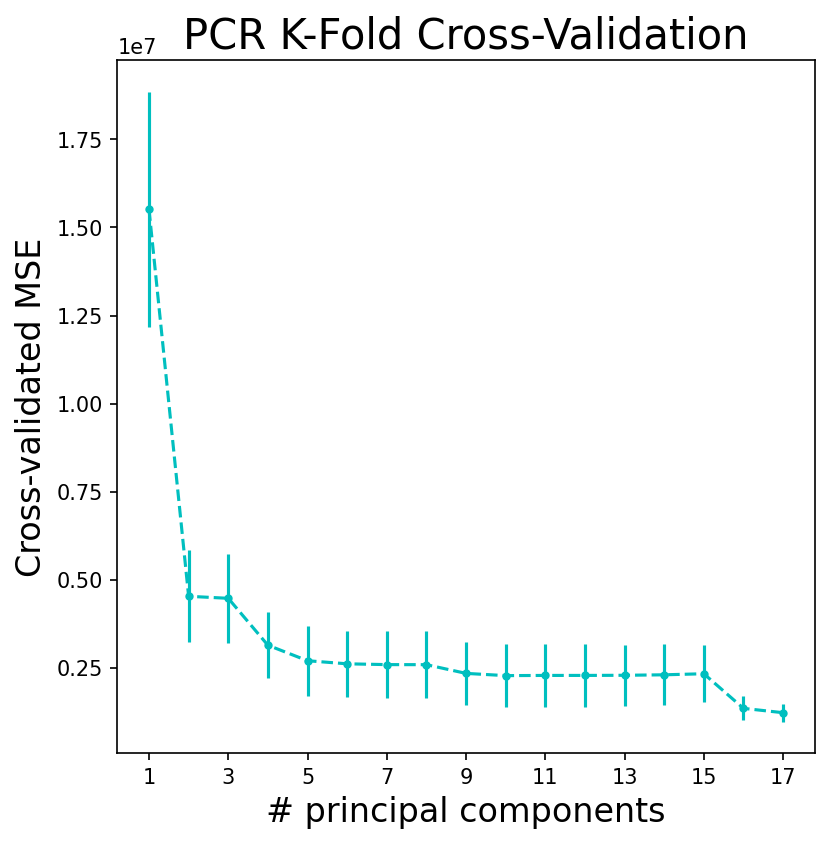

In [1466]:
# Plot results
fig, ax = plt.subplots(figsize=(6,6), dpi=150)
n_comp = param_grid_pca['pca__n_components']
ax.errorbar(
    n_comp,
    -grid_pca.cv_results_['mean_test_score'],
    grid_pca.cv_results_['std_test_score'] / np.sqrt(k),
    fmt='.',
    c='c'
)
ax.plot(
    n_comp, 
    -grid_pca.cv_results_['mean_test_score'],
    ls='--',
    c='c'
)
ax.set_title('PCR K-Fold Cross-Validation', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=16)
ax.set_xlabel('# principal components', fontsize=16)
ax.set_xticks(n_comp[::2]);

# # Set limite to y axis
# limite_min = 0.9 * np.min(-grid_pca.cv_results_['mean_test_score'])
# limite_max = 1.1 * np.max(-grid_pca.cv_results_['mean_test_score'])
# ax.set_ylim([limite_min, limite_max]);

In [1467]:
limite_min

1110930.7409672749

In [1468]:
limite_max

17063350.825123027

In [1469]:
# Compute MSE on test dataset
y_hat = grid.predict(X_test)
rss = sum((y_test - y_hat)**2)
mse_pcr = rss / len(y_hat)

# Print MSE on test dataset
print(f"""
Test MSE: {round(mse_pcr)}
""")


Test MSE: 1755114



In [1470]:
# Initiate test_mse list
test_mse = []

# Loop through all n_components
for i in range(1, X_train.shape[1] + 1):
    # Set up PCA method
    pca = PCA(n_components=i)
    linreg = LinearRegression()
    pipe = Pipeline([
        ('scaler', scaler),
        ('pca', pca),
        ('linreg', linreg)
    ])
    # Compute pipe on train dataset
    pipe.fit(X_train, y_train)

    # Compute MSE on test dataset
    y_hat = pipe.predict(X_test)
    rss = sum((y_test - y_hat)**2)
    mse = rss / len(y_hat)

    # Append MSE to the list
    test_mse.append(mse)

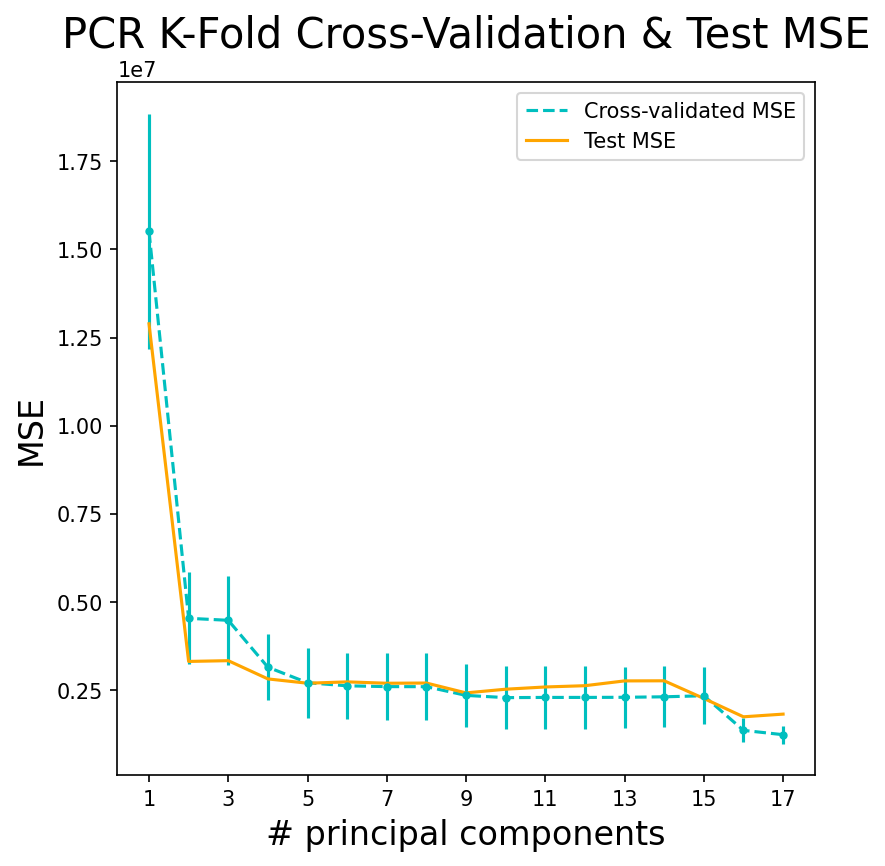

In [1471]:
# Plot the results again
fig, ax = plt.subplots(figsize=(6,6), dpi=150)
n_comp = param_grid_pca['pca__n_components']
ax.errorbar(
    n_comp,
    -grid_pca.cv_results_['mean_test_score'],
    grid_pca.cv_results_['std_test_score'] / np.sqrt(k),
    fmt='.',
    c='c'
)
ax.plot(
    n_comp, 
    -grid_pca.cv_results_['mean_test_score'],
    ls='--',
    c='c',
    label='Cross-validated MSE'
)
ax.plot(n_comp, test_mse, label='Test MSE', c='orange')

ax.set_title('PCR K-Fold Cross-Validation & Test MSE', fontsize=20)
ax.set_ylabel('MSE', fontsize=16)
ax.set_xlabel('# principal components', fontsize=16)
ax.set_xticks(n_comp[::2])

# Add legend
ax.legend();

The plot above demonstrates that the k-fold cross-validation approach with PCR yields results comparable to training PCR on the training dataset for each number of components an then evaluating the MSE on the test dataset.

Using k-fold cross-validation, the optimal number of components is determined to be 17, the maximum possible components available. The corresponding test MSE is 1,817,983, which is the same to the results obtained with Ridge regularization method.

#### 9f)

In [1472]:
# Set up PLS method
pls = PLSRegression(scale=True)

# Range of components to test
n_components = range(1, X.shape[1] + 1)

# Set up param_grid
param_grid_pls = {'n_components': n_components}

# Grid search the best number of PCAs components
grid_pls = GridSearchCV(
    estimator=pls,
    param_grid=param_grid_pls,
    cv=kfold,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Perform Grid Search with cross-validation
grid_pls.fit(X_train, y_train)

# Extract the best model info
best_n_components = grid_pls.best_params_['n_components']
best_score = -grid_pls.best_score_
best_model = grid_pls.best_estimator_

# Print information
print(f"""
Best n_components: {best_n_components}

Best MSE: {round(best_score)}

Best model: {best_model}
""")


Best n_components: 17

Best MSE: 1234367

Best model: PLSRegression(n_components=17)



In [1473]:
# Compute MSE on test dataset
y_hat = best_model.predict(X_test)
rss = sum((y_test - y_hat)**2)
mse_pls = rss / len(y_hat)

# Print MSE on test dataset
print(f"""
Test MSE: {round(mse_pls)}
""")


Test MSE: 1817983



In [1474]:
# Initialize test mse list
test_mse_pls = []

# Loop through all n_components:
for i in range(1, X.shape[1] + 1):
    pls = PLSRegression(n_components=i, scale=True)
    pls.fit(X_train, y_train)

    # Compute MSE on test dataset
    y_hat = pls.predict(X_test)
    rss = sum((y_test - y_hat)**2)
    mse = rss / len(y_hat)

    # Updated test MSE list
    test_mse_pls.append(mse)

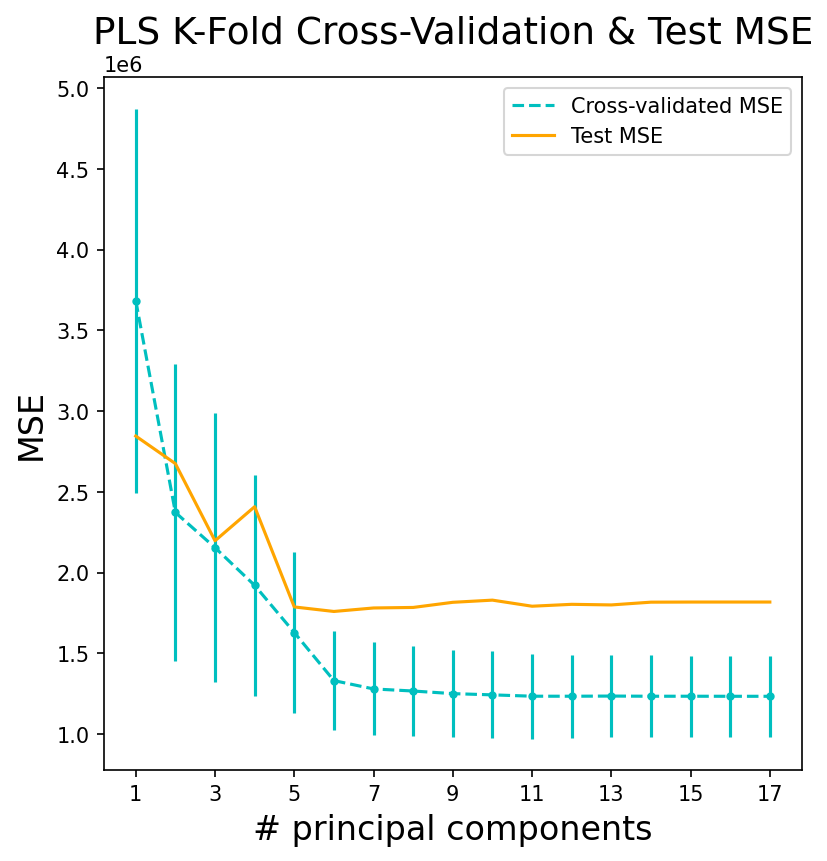

In [1475]:
# Plot the results again
fig, ax = plt.subplots(figsize=(6,6), dpi=150)
n_comp = param_grid_pls['n_components']
ax.errorbar(
    n_comp,
    -grid_pls.cv_results_['mean_test_score'],
    grid_pls.cv_results_['std_test_score'] / np.sqrt(k),
    fmt='.',
    c='c'
)
ax.plot(
    n_comp, 
    -grid_pls.cv_results_['mean_test_score'],
    ls='--',
    c='c',
    label='Cross-validated MSE'
)
ax.plot(n_comp, test_mse_pls, label='Test MSE', c='orange')

ax.set_title('PLS K-Fold Cross-Validation & Test MSE', fontsize=18)
ax.set_ylabel('MSE', fontsize=16)
ax.set_xlabel('# principal components', fontsize=16)
ax.set_xticks(n_comp[::2])

# Add legend
ax.legend();

When performing Partial Least Squares (PLS) with k-fold cross-validation on the training dataset, we observe a similar trend: the highest numberf of components produces the best results and the lowest test MSE of 1,234,367.

However, PLS demonostrates faster stabilization compared to Principal Component Regression (PCR). With just six components, the model achieves near-optimal performance, showing diminishing returns from adding more components. Interestingly, the test MSE is minimized with six components, and further additions result in a gradual increase in MSE.

Unlike PCA, PLS incorporates information from the endogenous variable (y) during its computations. This increases the risk of overfitting, especially with a high number of components.

#### 9g)

#### **Residual Standard Error (RSE)**

The Residual Standard Error (RSE) is calculated as follows ('slide' 87):

$${RSE} = \sqrt{\frac{\text{RSS}}{n - p - 1}}$$

Where:

- $RSS$ is the Residual Sum of Squares: $RSS = \sum (y - \hat{y})^2$
- $n$ is the number of observations.
- $p$ is the number of predictors (or components, if using PCR)
  
#### **Example:**
If we have an RSE of 3,260 and the mean value of $y$ is 14,000, the percentage error is:

    3,260 / 14,000 = 23%

In [1476]:
# Build a dataframe with all test MSE
results_df = pd.DataFrame(columns=['model', 'test_mse'])

# Add OLS result
results_df.loc[len(results_df)] = 'ols', mse_ols

# Add Ridge result
results_df.loc[len(results_df)] = 'ridge', mse_ridge

# Add Lasso result
results_df.loc[len(results_df)] = 'lasso', mse_lasso

# Add PCR result
results_df.loc[len(results_df)] = 'pcr', mse_pcr

# Add PLS result
results_df.loc[len(results_df)] = 'pls', mse_pls

In [1477]:
# Compute Residual Standar Error - RSE
n = X_test.shape[0]
p = X_test.shape[1]
rse_ols = np.sqrt(mse_ols / (n - p - 1))
rse_ridge = np.sqrt(mse_ridge / (n - p - 1))
rse_lasso = np.sqrt(mse_lasso / (n - 12 - 1))
rse_pcr = np.sqrt(mse_pcr / (n - 17 - 1))
rse_pls = np.sqrt(mse_pls / (n - 17 - 1))

# Add RSE to dataframe
results_df['test_rse'] = rse_ols, rse_ridge, rse_lasso, rse_pcr, rse_pls

In [1478]:
# Set float format to avoid scientific notation
pd.options.display.float_format = '{:,.2f}'.format

# Show overall dataframe
results_df

,model,test_mse,test_rse
0,ols,"11,044,132.66",249.79
1,ridge,"1,817,982.58",101.35
2,lasso,"1,755,113.92",98.20
3,pcr,"1,755,113.92",99.58
4,pls,"1,817,982.65",101.35


The summary above reveals that Lasso and PCR achieve the same MSE on the test dataset. However, Lasso has a slight advantage due to a lower Residual Standard Error (RSE), as the 'optimal' Lasso model filters out 5 features.

In [1479]:
# Get the mean value of y_test
print(f"""
y_test mean: {round(y_test.mean()):,.0f} college applications
""")


y_test mean: 3,232 college applications



In [1480]:
# Compute percentage of error of lasso
error_pct_lasso = (rse_lasso / y_test.mean()) * 100

# Print
print(f"""
Lasso's percentage error: {error_pct_lasso:.2f}%
""")


Lasso's percentage error: 3.04%



Based on the evaluation of MSE, RSE, and percentage error, we can conclude that Lasso is the best-performing model, demonstrating its ability to accurately predict the number of college applications received. For a more thorough analysis, it is recommended to examine predictions for values further from the mean, focusing on both tails of the distribution to asses how the model performs across the entire range of data.

Among the five models evaluated, OLS stands out negatively, with significantly worse performance compared to the other four models, which exhibits similar results.

Lasso's final percentage error of 3.04% confirms its accuracy and suitability for the task, but with a note to further test it on values on both tails of the distribution.

---

### Question 10

####  10a)

In [1481]:
# Set seed
np.random.seed(42)

# Data variables
n = 1000
p = 20
non_zero_coeffs = 10

# Generate 'X' matrix
X = np.random.normal(size=(n, p))

# Generate 'Beta' vector - coefficients
beta = np.zeros(p)
non_zero = np.random.randint(low=1, high=10, size=non_zero_coeffs)
sample = np.random.choice(range(p), size=non_zero_coeffs, replace=False)
beta[sample] = non_zero

# Generate the error term
error = np.random.normal(size=n)

# Generate Y
Y = np.matmul(X, beta) + error

#### 10b)

In [1482]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.9, random_state=42)

#### 10c)

In [1483]:
# Perform best subset selection
path = fit_path(X_train, y_train, max_nonzeros=X_train.shape[1])

Preprocessing Data.
BnB Started.
Iteration: 1. Number of non-zeros:  1
Iteration: 2. Number of non-zeros:  1
Iteration: 3. Number of non-zeros:  2
Iteration: 4. Number of non-zeros:  2
Iteration: 5. Number of non-zeros:  4
Iteration: 6. Number of non-zeros:  4
Iteration: 7. Number of non-zeros:  5
Iteration: 8. Number of non-zeros:  5
Iteration: 9. Number of non-zeros:  6
Iteration: 10. Number of non-zeros:  6
Iteration: 11. Number of non-zeros:  7
Iteration: 12. Number of non-zeros:  8
Iteration: 13. Number of non-zeros:  8
Iteration: 14. Number of non-zeros:  9
Iteration: 15. Number of non-zeros:  9
Iteration: 16. Number of non-zeros:  9
Iteration: 17. Number of non-zeros:  10
Iteration: 18. Number of non-zeros:  10
Iteration: 19. Number of non-zeros:  10
Iteration: 20. Number of non-zeros:  10
Iteration: 21. Number of non-zeros:  10
Iteration: 22. Number of non-zeros:  10
Iteration: 23. Number of non-zeros:  10
Iteration: 24. Number of non-zeros:  10
Iteration: 25. Number of non-zer

In [1484]:
# Initialize a dict to hold model's info
model_info = {
    'coeffs': [],
    'nonzeros': [],
    'mse_train': [],
    'mse_test': []
}

# Loop through each subset selection
for i in range(len(path)):
    coeffs = path[i]['B']
    intercept = path[i]['B0']
    nonzeros = len(np.where(coeffs != 0)[0])

    # Skip if coefficients already exist in 'model_info'
    if any(np.array_equal(coeffs, existing_coeffs) for existing_coeffs in model_info['coeffs']):
        continue

    # Predict on data
    y_hat_train = np.matmul(X_train, coeffs) + intercept
    y_hat_test = np.matmul(X_test, coeffs) + intercept

    # Compute MSE
    mse_train = sum((y_train - y_hat_train)**2) / len(y_train)
    mse_test = sum((y_test - y_hat_test)**2) / len(y_test)
    
    # Update dict
    model_info['coeffs'].append(coeffs)
    model_info['nonzeros'].append(nonzeros)
    model_info['mse_train'].append(mse_train)
    model_info['mse_test'].append(mse_test)

In [1485]:
# Check for non-zeros coefficients
model_info['nonzeros']

[1, 1, 2, 4, 5, 6, 7, 8, 9, 10, 17, 19, 20]

We see two models with only a single feature, so we need to select the one with the best performance. 

In [1486]:
model_info['mse_train']

[193.6284181674058,
 193.62838510130837,
 127.7486709288246,
 58.2147443989827,
 34.76774459870786,
 21.522064453955554,
 11.841392493599958,
 5.835891578829632,
 1.9196992112087086,
 0.8962368983890532,
 0.759532455443892,
 0.7372854737209283,
 0.7368008673403955]

In [1487]:
# Drop the first model or observation in the dictionary
for key in model_info.keys():
    del model_info[key][0]

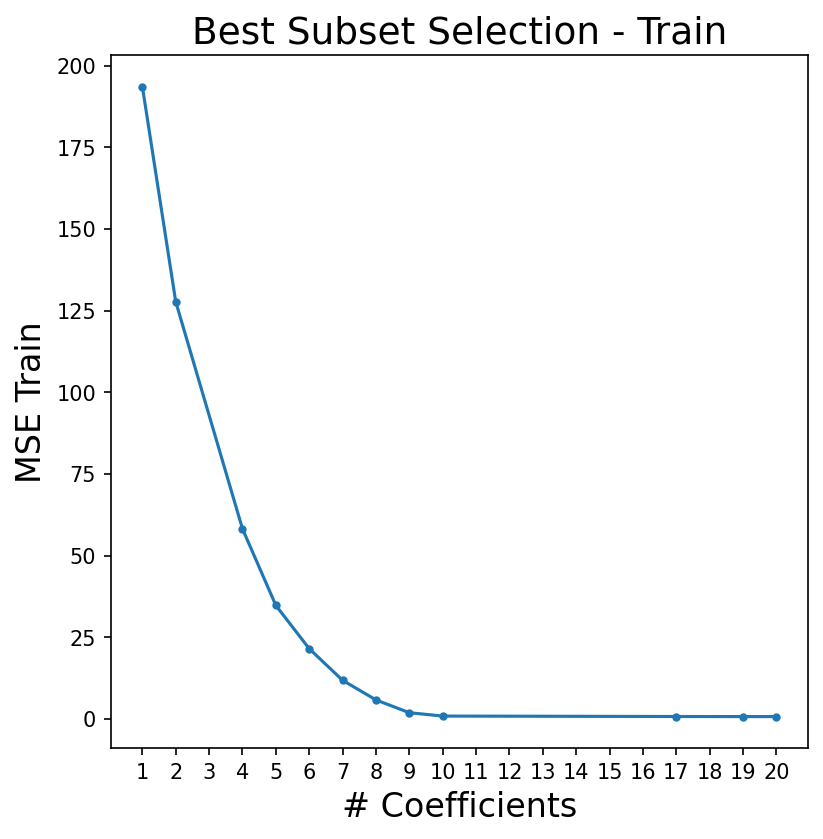

In [1488]:
# Plot training MSE
fig, ax = plt.subplots(figsize=(6,6), dpi=150)
ax.plot(model_info['nonzeros'], model_info['mse_train'], marker='.')
ax.set_title('Best Subset Selection - Train', fontsize=18)
ax.set_ylabel('MSE Train', fontsize=16)
ax.set_xlabel('# Coefficients', fontsize=16)
ax.set_xticks(range(1,21));

#### 10d)

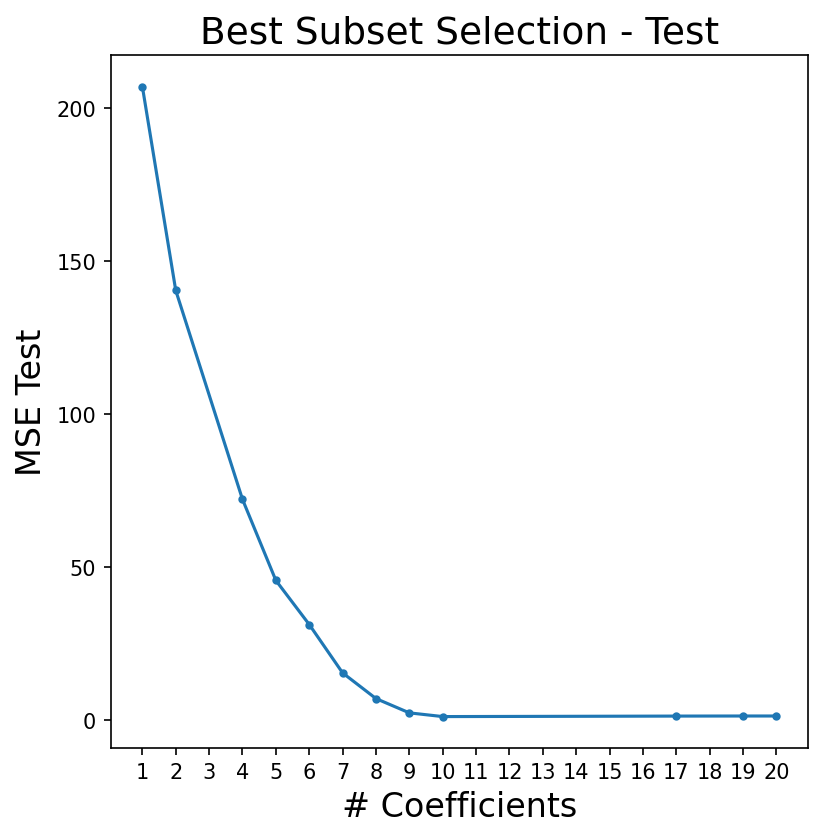

In [1489]:
# Plot test MSE
fig, ax = plt.subplots(figsize=(6,6), dpi=150)
ax.plot(model_info['nonzeros'], model_info['mse_test'], marker='.')
ax.set_title('Best Subset Selection - Test', fontsize=18)
ax.set_ylabel('MSE Test', fontsize=16)
ax.set_xlabel('# Coefficients', fontsize=16)
ax.set_xticks(range(1,21));

#### 10e)

In [1490]:
# Show test MSE
for i,j in zip(model_info['mse_test'], model_info['nonzeros']):
    print(i, '\t', j)

207.15059760951402 	 1
140.51010156332802 	 2
72.18381885791696 	 4
45.68450553754254 	 5
31.27020428376239 	 6
15.451005742043742 	 7
7.049849341223723 	 8
2.3816351629378456 	 9
1.166656868286443 	 10
1.3297577937381486 	 17
1.3555473704413443 	 19
1.357291075246679 	 20


By looking at the plot alone, it can be challenging to determine which model achieves the lowest MSE on the test dataset. The model with 10 features stands out as having the lowest MSE. This aligns with the number of features used to generate the data, indicating that the model succesfully captures the underlying structure of the data.

#### 10f)

In [1491]:
# Get the estimated coeffs
coeffs_loc = np.where(np.array(model_info['nonzeros']) == 10)[0][0]
coeffs_estimated = model_info['coeffs'][coeffs_loc]
coeffs_estimated

array([0.98869654, 4.83585942, 0.        , 0.        , 0.        ,
       0.        , 2.77572327, 8.81841725, 3.9919725 , 6.85842856,
       8.00311947, 0.        , 0.        , 0.        , 3.97371226,
       4.97431629, 1.93477771, 0.        , 0.        , 0.        ])

In [1492]:
# Show the true coeffs
beta

array([1., 5., 0., 0., 0., 0., 3., 9., 4., 7., 8., 0., 0., 0., 4., 5., 2.,
       0., 0., 0.])

It is reasonable to conclude that the best-performing model has predicted coefficient values that closely align with the true values.

#### 10g)

In [1493]:
coeffs_distance = []
for i in range(len(model_info['coeffs'])):
    diff = np.sqrt(sum((beta - model_info['coeffs'][i])**2))
    coeffs_distance.append(diff)

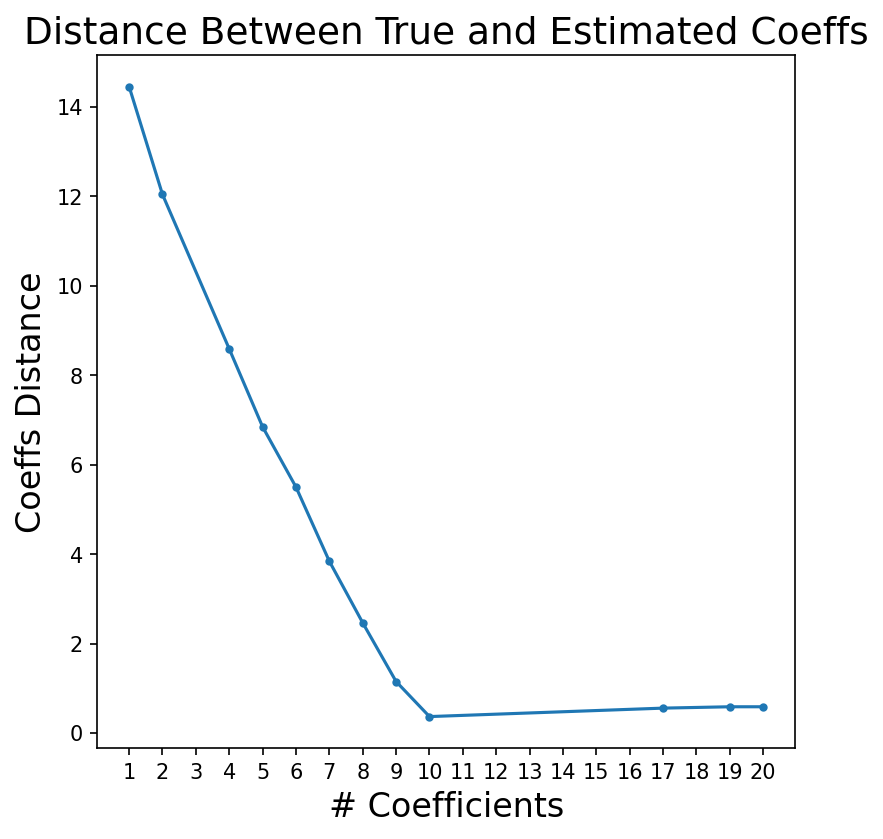

In [1494]:
# Plot findings
fig, ax = plt.subplots(figsize=(6,6), dpi=150)
ax.plot(model_info['nonzeros'], coeffs_distance, marker='.')
ax.set_title('Distance Between True and Estimated Coeffs', fontsize=18)
ax.set_ylabel('Coeffs Distance', fontsize=16)
ax.set_xlabel('# Coefficients', fontsize=16)
ax.set_xticks(range(1,21));

The plot presents a similar trend when compared to the test MSE plot, but with a more gradual decline and convergence toward the optimal model. Both, the plots and the accompanying data, indicate that the model with 10 coefficients delivers the best results.

---

### Question 11

#### 11a)

In [1495]:
# Load Boston dataset
boston = pd.read_csv('data/Boston.csv')

In [1496]:
# Print some basic information
boston.info()
boston.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 55.5 KB


,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.01,18.00,2.31,0,0.54,6.58,65.20,4.09,1,296,15.30,4.98,24.00
1,2,0.03,0.00,7.07,0,0.47,6.42,78.90,4.97,2,242,17.80,9.14,21.60
2,3,0.03,0.00,7.07,0,0.47,7.18,61.10,4.97,2,242,17.80,4.03,34.70
3,4,0.03,0.00,2.18,0,0.46,7.00,45.80,6.06,3,222,18.70,2.94,33.40
4,5,0.07,0.00,2.18,0,0.46,7.15,54.20,6.06,3,222,18.70,5.33,36.20


In [1497]:
# Remove first column
boston = boston.iloc[:, 1:]

# Get exogenous & endogenous variables
y = boston['crim']
X = boston.iloc[:, 1:].copy()

In [1498]:
# Split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Standardize train and test datasets
X_train_s = (X_train - X_train.mean()) / X_train.std()
X_test_s = (X_test - X_train.mean()) / X_train.std()

# Add intercept
X_train_s.insert(0, 'intercept', np.ones(len(X_train_s)))
X_test_s.insert(0, 'intercept', np.ones(len(X_test_s)))

In [1499]:
#######
# OLS #
#######
model_ols = OLS(y_train, X_train_s).fit()

# Predict on test dataset
y_hat = model_ols.predict(X_test_s)
mse_ols = sum((y_test - y_hat)**2) / len(y_hat)
round(mse_ols, 2)

48.18

A simple linear regression model using all features, fitted on the training dataset, yields an MSE of approximately 48.18 on the test dataset.

In [1500]:
###########################
# OLS + FORWARD SELECTION #
###########################
# Perform forward stepwise selection
features, scores = forward_step(np.array(X_train_s), np.array(y_train), compute_mse)

# Compute score for the null model - only intercept
null_model = OLS(y_train, X_train_s.iloc[:, 0]).fit()
y_hat = null_model.predict(X_test_s.iloc[:, 0])
mse_null_model = sum((y_test - y_hat)**2) / len(y_hat)

# Update scores with null model result
scores = [mse_null_model] + scores

# Print results
for i, j in zip(features, scores):
    print(round(j, 2), '\t', i)

88.55 	 0
42.02 	 8
40.48 	 12
40.18 	 10
39.91 	 7
39.46 	 1
39.08 	 4
39.02 	 3
39.0 	 9
39.06 	 6
39.17 	 2
39.37 	 11
40.02 	 5


In [1501]:
# Get the min score threshold
min_score_threshold = np.argmin(scores)
features_filtered = features[:min_score_threshold + 1]

# Filter dataset and train the model
model_ols2 = OLS(y_train, X_train_s.iloc[:, features_filtered]).fit()

# Predict on test dataset
y_hat = model_ols2.predict(X_test_s.iloc[:, features_filtered])
mse_ols2 = sum((y_test - y_hat)**2) / len(y_test)
round(mse_ols2, 2)

48.75

Using forward stepwise feature selection, we can eliminate 4 out of 13 features while maintaining a comparable MSE on the test dataset (~49.03 vs ~48.75).

In [1502]:
#########
# LASSO #
#########
lasso = Lasso()

# lambdas to test
lambdas = 10**np.linspace(6, -2, 100) / y_train.std()

# Param grid for GridSearchCV
param_grid = {'alpha': lambdas}

# Set up k-fold cross-validation
k = 5
kfold = KFold(n_splits=k, shuffle=True, random_state=42)

grid_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    cv=kfold
)
    
grid_lasso.fit(X_train_s, y_train)

# Extract the best model info
best_lambda = grid_lasso.best_params_['alpha']
best_score = -grid_lasso.best_score_
best_model = grid_lasso.best_estimator_

# Print information
print(f"""
Best lambda: {best_lambda}

Best train MSE: {round(best_score, 2)}

Best model: {best_model}
""")


Best lambda: 0.059863289412938545

Best train MSE: 39.87

Best model: Lasso(alpha=0.059863289412938545)



In [1503]:
# Compute test MSE
y_hat = best_model.predict(X_test_s)
mse_lasso = sum((y_test - y_hat)**2) / len(y_hat)

# Print information
print(f"""
Lasso test MSE: {round(mse_lasso, 2)}
""")


Lasso test MSE: 48.69



In [1504]:
# Get the coeffs from best lasso
lasso_best = Lasso(alpha=grid_lasso.best_params_['alpha'])
lasso_best.fit(X_train_s, y_train)
lasso_best.coef_

array([ 0.        ,  0.74060397, -0.10809547, -0.2206306 , -0.88888823,
        0.25031959,  0.05382666, -1.67023053,  4.62861158, -0.        ,
       -0.50028519,  0.34572398, -1.69324202])

When applying the Lasso regularization method, the optimal results is achieved with an alpha of ~0.06, yielding a test MSE of around 48.69. The model utilizes 11 out of 13 features to achieve this performance.

In [1505]:
#########
# RIDGE #
#########
ridge = Ridge()

# Lambdas to test (for completeness)
lambdas = 10**np.linspace(6, -2, 100) / y_train.std()

# Set up a grid search (for completeness)
param_grid = {'alpha': lambdas}

# K-fold cross-validation (for completeness)
k = 5
kfold = KFold(
    n_splits=k,
    shuffle=True,
    random_state=42
)

# Set up grid search
grid_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    cv=kfold
)

# Fit
grid_ridge.fit(X_train_s, y_train)

# Extract the best model info
best_lambda = grid_ridge.best_params_['alpha']
best_score = -grid_ridge.best_score_
best_model = grid_ridge.best_estimator_

# Print information
print(f"""
Best lambda: {best_lambda}

Best train MSE: {round(best_score, 2)}

Best model: {best_model}
""")


Best lambda: 5.206603626032301

Best train MSE: 39.95

Best model: Ridge(alpha=5.206603626032301)



In [1506]:
# Compute test MSE
y_hat = best_model.predict(X_test_s)
mse_ridge = sum((y_test - y_hat)**2) / len(y_hat)

# Print information
print(f"""
Ridge test MSE: {round(mse_ridge, 2)}
""")


Ridge test MSE: 48.3



Ridge regularization delivers optimal performance with a lambda value of approximately 5.2, resulting in a test MSE of around 48.3.

In [1529]:
#######
# PCR #
#######
pca = PCA()

# Set up the linear regression
linreg = LinearRegression()

# Set up a pipeline
pipe = Pipeline([
    ('pca', pca),
    ('linreg', linreg)
])

# Number of components to test
n_components = range(1, X_train.shape[1] + 1)

# Set up param grid
param_grid = {'pca__n_components': n_components}

# K-fold cross-validation (for completeness)
k = 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid search
grid_pca = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    cv=kfold
)

# Fit
grid_pca.fit(X_train_s, y_train)

# Extract the best model info
best_n_components = grid_pca.best_params_['pca__n_components']
best_score = -grid_pca.best_score_
best_model = grid_pca.best_estimator_

# Print information
print(f"""
Best n_components: {best_n_components}

Best train MSE: {round(best_score)}

Best model: {best_model}
""")


Best n_components: 12

Best train MSE: 40

Best model: Pipeline(steps=[('pca', PCA(n_components=12)), ('linreg', LinearRegression())])



In [1530]:
# Compute MSE on test dataset
y_hat = grid_pca.predict(X_test_s)
mse_pcr = sum((y_test - y_hat)**2) / len(y_test)

# Print
print(f"""
PCR test MSE: {round(mse_pcr, 2)}
""")


PCR test MSE: 48.18



When using Principal Component Regression (PCR) for model selection, the best-performing model utilizes all features in the dataset, achieving a test MSE of approximately 48.18. This result is comparable to the OLS model, which also incorporate all features.

In [1509]:
# Convert data to numpy array
X_train_array = np.array(X_train)
X_test_array = np.array(X_test)
X_train_s_array = np.array(X_train_s)
X_test_s_array = np.array(X_test_s)

y_train_array = np.array(y_train)
y_test_array = np.array(y_test)

In [1510]:
#########################
# BEST SUBSET SELECTION #
#########################
path = fit_path(X_train_s_array[:, 1:], y_train_array, max_nonzeros=X_train_s_array[:, 1:].shape[1])

"""
obs: X_train_array has an intercept that we left out of the dataset before applying the method.
"""

Preprocessing Data.
BnB Started.
Iteration: 1. Number of non-zeros:  1
Iteration: 2. Number of non-zeros:  1
Iteration: 3. Number of non-zeros:  1
Iteration: 4. Number of non-zeros:  1
Iteration: 5. Number of non-zeros:  2
Iteration: 6. Number of non-zeros:  8
Iteration: 7. Number of non-zeros:  8
Iteration: 8. Number of non-zeros:  11
Iteration: 9. Number of non-zeros:  12


'\nobs: X_train_array has an intercept that we left out of the dataset before applying the method.\n'

In [1511]:
# Initialize a dict to hold method's info
method_info = {
    'coeffs': [],
    'nonzeros': [],
    'mse_train': [],
    'mse_test': []
}

# Loop through best subset selection
for i in range(len(path)):
    coeffs = path[i]['B']
    intercept = path[i]['B0']
    nonzeros = len(np.where(coeffs != 0)[0])

    # Check if coeffs already in the dict
    if any(np.array_equal(coeffs, existing_coeffs) for existing_coeffs in method_info['coeffs']):
        continue

    # Predict
    y_hat_train = np.matmul(X_train_s_array[:, 1:], coeffs) + intercept
    y_hat_test = np.matmul(X_test_s_array[:, 1:], coeffs) + intercept

    # Compute MSE
    mse_train = sum((y_train - y_hat_train)**2) / len(y_train)
    mse_test = sum((y_test - y_hat_test)**2) / len(y_test)

    # Update dict
    method_info['coeffs'].append(coeffs)
    method_info['nonzeros'].append(nonzeros)
    method_info['mse_train'].append(mse_train)
    method_info['mse_test'].append(mse_test)

In [1512]:
# Show test MSE
for i,j in zip(method_info['mse_test'], method_info['nonzeros']):
    print(i, '\t', j)

53.93196245659332 	 1
53.931902280700285 	 1
49.65889655021011 	 2
48.94698082019345 	 8
48.33351074242703 	 11
48.375631935750924 	 12


Best Subset Selection achieves the lowest test MSE of ~48.33 when using 12 out of 13 features, including the intercept as one of the parameters.

In [1513]:
# Create a dataframe to hold overall information
results_df = pd.DataFrame(columns=['model', 'mse_test'])

# Add models' info
results_df.loc[len(results_df)] = 'ols', round(mse_ols, 2)
results_df.loc[len(results_df)] = 'ols + selection', round(mse_ols2, 2)
results_df.loc[len(results_df)] = 'lasso', round(mse_lasso, 2)
results_df.loc[len(results_df)] = 'ridge', round(mse_ridge, 2)
results_df.loc[len(results_df)] = 'pcr', round(mse_pcr, 2)
results_df.loc[len(results_df)] = 'best subset selection', round(min(method_info['mse_test']), 2)

In [1514]:
# Compute Residual Standar Error - RSE
n = X_test_s.shape[0]
p = X_test_s.shape[1]
rse_ols = np.sqrt(mse_ols / (n - p - 1))
rse_ols2 = np.sqrt(mse_ols2 / (n - 9 - 1)) # selected 9 features
rse_ridge = np.sqrt(mse_ridge / (n - p - 1))
rse_lasso = np.sqrt(mse_lasso / (n - 11 - 1)) # selected 11 features
rse_pcr = np.sqrt(mse_pcr / (n - p - 1))
rse_best_subset = np.sqrt(min(method_info['mse_test']) / (n - 12 - 1)) # selected 12 features

# Add RSE to dataframe
results_df['test_rse'] = rse_ols, rse_ols2, rse_lasso, rse_ridge, rse_pcr, rse_best_subset

In [1515]:
# Set float format to avoid scientific notation
pd.options.display.float_format = '{:,.3}'.format

# Show overall results
results_df

,model,mse_test,test_rse
0,ols,48.2,0.653
1,ols + selection,48.8,0.646
2,lasso,48.7,0.651
3,ridge,48.3,0.654
4,pcr,48.2,0.653
5,best subset selection,48.3,0.651


The results across all methods are quite similar, with OLS and Ridge, both using all features, achieving the lowest test MSE.

It is worth noting that when applying Best Subset Selection and Forward Stepwise Selection, there is minimal improvement in accuracy once the model includes 3 features (including the intercept). This highlights the diminishing returns of adding additional features beyond a certain point.

#### 11b) & c)

In [1520]:
# Compute percentage of error
error_pct = (rse_lasso / y_test.mean()) * 100

# Print
print(f"""
Percentage error: {error_pct:.2f}%
""")


Percentage error: 16.08%



In [1568]:
# Select features - forward selection
features_name = [
    'intercept',
    'rad',
    'medv',
    'ptratio'
]

# Restricted OLS
ols_restricted = OLS(y_train, X_train_s[features_name]).fit()

# Predict & compute test MSE
y_hat = ols_restricted.predict(X_test_s[features_name])
mse = sum((y_test - y_hat)**2) / len(y_test)

# Print
print(f"""
OLS 4 features test MSE: {mse:.4f}
""")


OLS 4 features test MSE: 50.5061



In [1570]:
# Compute RSE
rse = np.sqrt(mse / (n - 4 - 1))

# Print
print(f"""
OLS 4 features RSE: {rse:.4f}
""")


OLS 4 features RSE: 0.6434



All models have similar performance and percentage error, but we need to emphasize the immportance of restricting the number of features. As previously observed, adding more than 4 features (including the intercept) offers no notable improvement in accuracy.

Given these findings, OLS combined with feature selection seems the most effect approach. This is further supported by the lowest RSE value of ~0.6434, achieved with an OLS model using forward selection and choosing the first 4 features.

We should exercise caution when increasing a model's flexibility, particularly when there is no significant benefit in return. Overfitting remains a critical risk that can be challenging to detect and mitigate effectively.